In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)

n = 120

categories = ["Technology", "Furniture", "Office Supplies"]
regions = ["North", "South", "East", "West"]
segments = ["Consumer", "Corporate", "Home Office"]
products = ["Laptop", "Chair", "Printer", "Table", "Phone", "Notebook"]
ship_modes = ["Standard", "Second Class", "First Class"]

sales_df = pd.DataFrame({
    "Order_ID": range(1001, 1001 + n),
    "Order_Date": pd.date_range("2025-01-01", periods=n, freq="D"),
    "Category": np.random.choice(categories, n),
    "Product": np.random.choice(products, n),
    "Region": np.random.choice(regions, n),
    "Segment": np.random.choice(segments, n),
    "Ship_Mode": np.random.choice(ship_modes, n),
    "Quantity": np.random.randint(1, 10, n),
    "Sales": np.random.uniform(100, 5000, n).round(2)
})

sales_df["Profit"] = (
    sales_df["Sales"] * np.random.uniform(0.05, 0.30, n)
).round(2)

sales_df.head()

,Order_ID,Order_Date,Category,Product,Region,Segment,Ship_Mode,Quantity,Sales,Profit
0,1001,2025-01-01,Office Supplies,Phone,North,Corporate,Standard,9,4874.53,1226.19
1,1002,2025-01-02,Technology,Printer,West,Corporate,First Class,8,4932.43,1169.31
2,1003,2025-01-03,Office Supplies,Table,East,Corporate,First Class,3,3520.99,338.47
3,1004,2025-01-04,Office Supplies,Notebook,South,Consumer,Second Class,1,2726.87,279.06
4,1005,2025-01-05,Technology,Printer,West,Home Office,First Class,3,1616.69,230.57


In [3]:
print("Dataset Shape:", sales_df.shape)

print("\nColumn Names:")
print(sales_df.columns.tolist())

print("\nMissing Values:")
print(sales_df.isnull().sum())

print("\nDuplicate Records:")
print(sales_df.duplicated().sum())

print("\nDataset Information:")
sales_df.info()

Dataset Shape: (120, 10)

Column Names:
['Order_ID', 'Order_Date', 'Category', 'Product', 'Region', 'Segment', 'Ship_Mode', 'Quantity', 'Sales', 'Profit']

Missing Values:
Order_ID      0
Order_Date    0
Category      0
Product       0
Region        0
Segment       0
Ship_Mode     0
Quantity      0
Sales         0
Profit        0
dtype: int64

Duplicate Records:
0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order_ID    120 non-null    int64         
 1   Order_Date  120 non-null    datetime64[ns]
 2   Category    120 non-null    object        
 3   Product     120 non-null    object        
 4   Region      120 non-null    object        
 5   Segment     120 non-null    object        
 6   Ship_Mode   120 non-null    object        
 7   Quantity    120 non-null    int64         
 8   Sales       120 non-n

In [4]:
sales_df["Order_Date"] = pd.to_datetime(sales_df["Order_Date"])

sales_df["Month"] = sales_df["Order_Date"].dt.to_period("M").astype(str)

print("Data preparation completed successfully!")

sales_df.head()

Data preparation completed successfully!


,Order_ID,Order_Date,Category,Product,Region,Segment,Ship_Mode,Quantity,Sales,Profit,Month
0,1001,2025-01-01,Office Supplies,Phone,North,Corporate,Standard,9,4874.53,1226.19,2025-01
1,1002,2025-01-02,Technology,Printer,West,Corporate,First Class,8,4932.43,1169.31,2025-01
2,1003,2025-01-03,Office Supplies,Table,East,Corporate,First Class,3,3520.99,338.47,2025-01
3,1004,2025-01-04,Office Supplies,Notebook,South,Consumer,Second Class,1,2726.87,279.06,2025-01
4,1005,2025-01-05,Technology,Printer,West,Home Office,First Class,3,1616.69,230.57,2025-01


In [5]:
total_sales = sales_df["Sales"].sum()
total_profit = sales_df["Profit"].sum()
total_quantity = sales_df["Quantity"].sum()
average_sales = sales_df["Sales"].mean()
profit_margin = (total_profit / total_sales) * 100

print("SALES & REVENUE ANALYSIS")
print("-" * 35)
print(f"Total Sales          : {total_sales:.2f}")
print(f"Total Profit         : {total_profit:.2f}")
print(f"Total Quantity Sold  : {total_quantity}")
print(f"Average Sales/Order  : {average_sales:.2f}")
print(f"Profit Margin        : {profit_margin:.2f}%")

SALES & REVENUE ANALYSIS
-----------------------------------
Total Sales          : 312029.12
Total Profit         : 51471.30
Total Quantity Sold  : 618
Average Sales/Order  : 2600.24
Profit Margin        : 16.50%


In [6]:
category_analysis = sales_df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).reset_index()

category_analysis

,Category,Total_Sales,Total_Profit,Total_Quantity
0,Furniture,95313.50,14231.44,188
1,Office Supplies,115377.81,20063.04,222
2,Technology,101337.81,17176.82,208


In [7]:
region_analysis = sales_df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).reset_index()

region_analysis

,Region,Total_Sales,Total_Profit,Total_Quantity
0,East,90147.26,15504.36,137
1,North,61495.45,11340.99,126
2,South,46478.78,6723.15,113
3,West,113907.63,17902.80,242


In [8]:
region_analysis.to_csv("region_analysis.csv", index=False)

print("region_analysis.csv created successfully!")

region_analysis.csv created successfully!


In [9]:
segment_analysis = sales_df.groupby("Segment").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).reset_index()

segment_analysis

,Segment,Total_Sales,Total_Profit,Total_Quantity
0,Consumer,103642.79,17557.14,195
1,Corporate,126161.60,20947.07,252
2,Home Office,82224.73,12967.09,171


In [10]:
segment_analysis.to_csv("segment_analysis.csv", index=False)

print("segment_analysis.csv created successfully!")

segment_analysis.csv created successfully!


In [11]:
monthly_sales = sales_df.groupby("Month").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).reset_index()

monthly_sales

,Month,Total_Sales,Total_Profit
0,2025-01,94435.70,14999.71
1,2025-02,86265.73,13118.88
2,2025-03,75550.59,12626.41
3,2025-04,55777.10,10726.30


In [12]:
monthly_sales.to_csv("monthly_sales.csv", index=False)

print("monthly_sales.csv created successfully!")

monthly_sales.csv created successfully!


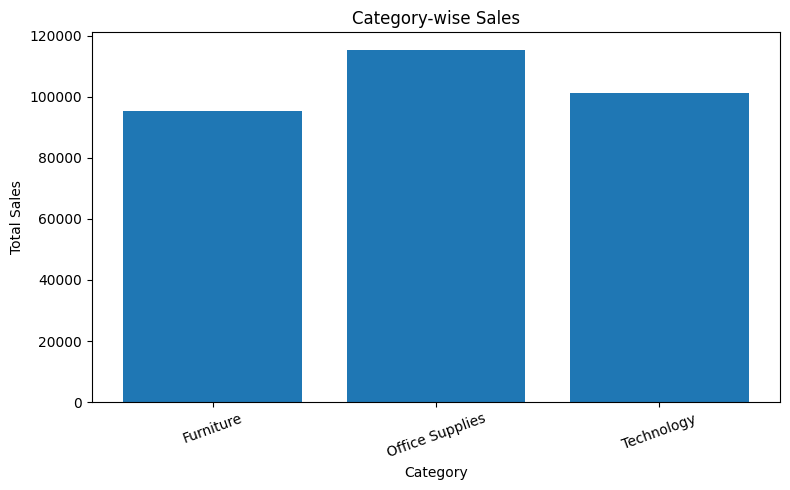

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis["Category"],
    category_analysis["Total_Sales"]
)

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

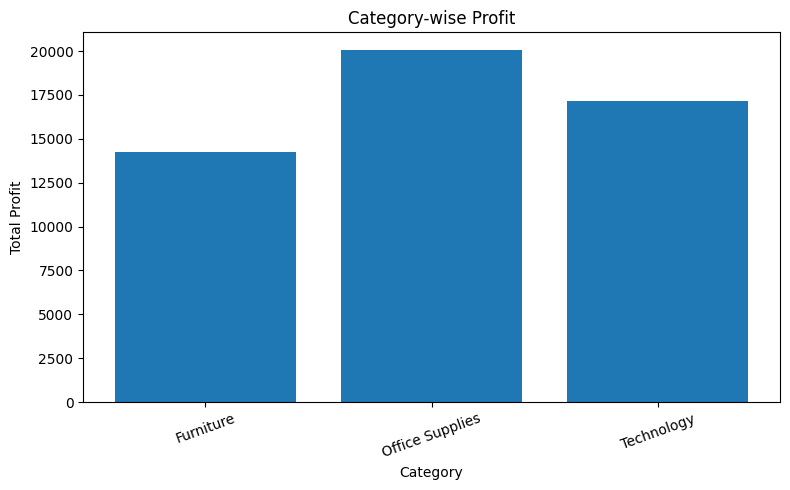

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis["Category"],
    category_analysis["Total_Profit"]
)

plt.title("Category-wise Profit")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

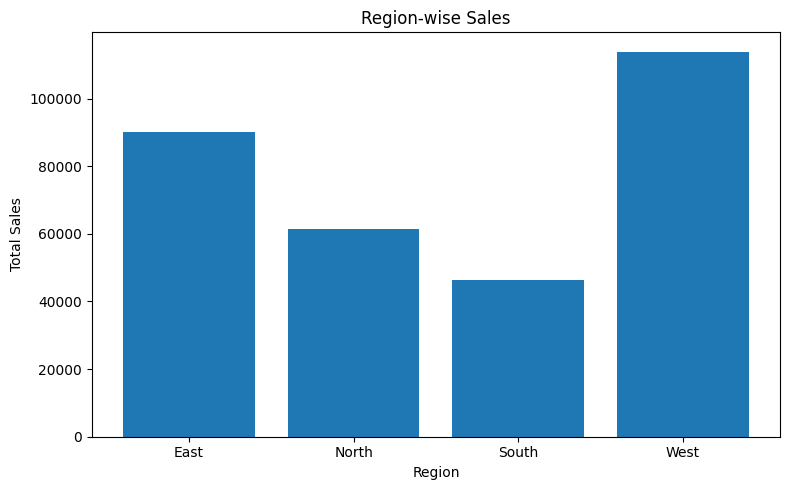

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_analysis["Region"],
    region_analysis["Total_Sales"]
)

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

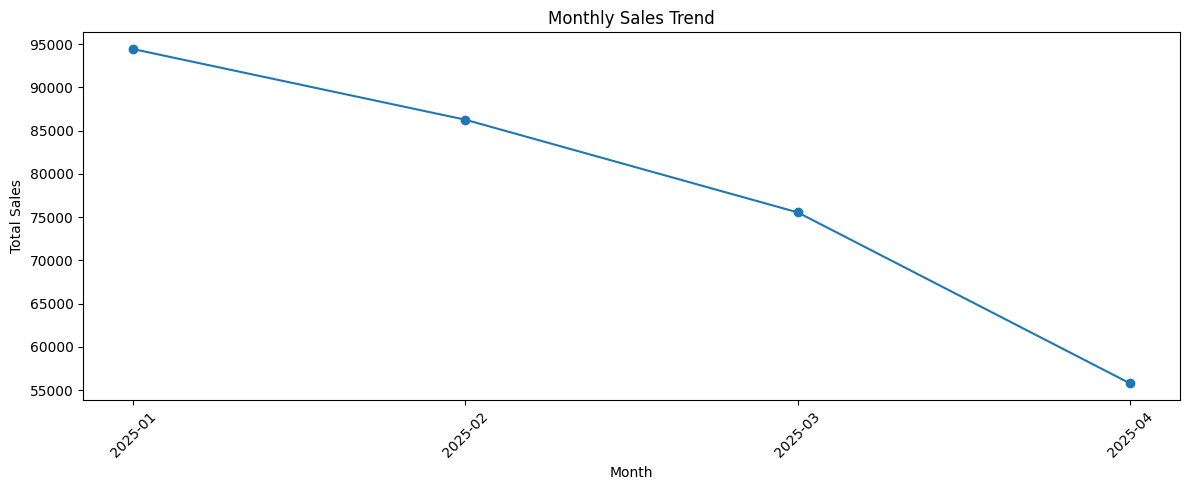

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Total_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

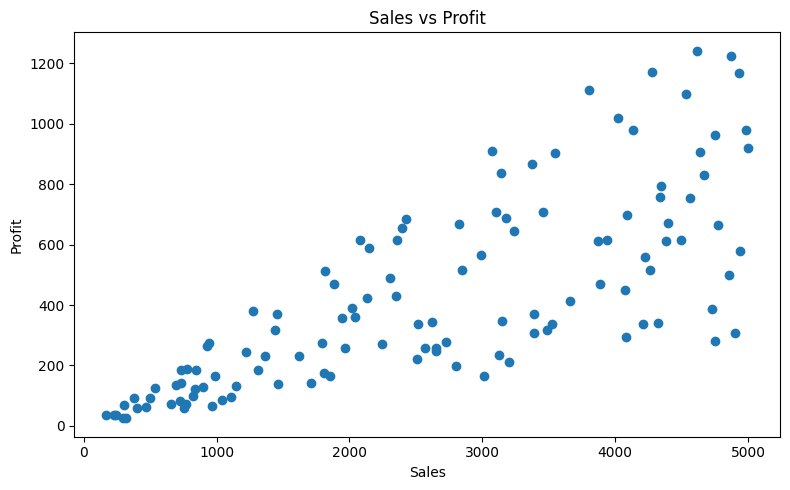

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    sales_df["Sales"],
    sales_df["Profit"]
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [18]:
sales_df.to_csv("sales_analysis_cleaned_dataset.csv", index=False)

print("All Module 1 files generated successfully!")

All Module 1 files generated successfully!


In [19]:
import os

print("Generated Files:")
for file in os.listdir():
    if file.endswith(".csv"):
        print(file)

Generated Files:
segment_analysis.csv
sales_analysis_cleaned_dataset.csv
region_analysis.csv
monthly_sales.csv
